In [4]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
import getdist
from getdist import loadMCSamples, plots
import warnings

In [7]:

choice = 0
filepaths = [
    '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_lcdm_baseline_mcmc/',
    '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_wcdm_baseline_mcmc/',
    '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/chains/lsst_lcdm_baseline_mcmc/',
    '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/chains/lsst_wcdm_baseline_mcmc/',
]

def load(filepath, settings):
    samples = loadMCSamples(filepath, settings=settings)
    p = samples.getParams()
    s8 = p.sigma8*(p.omegam/0.3)**0.5
    try:
        samples.addDerived(
            s8,
            'S8',
            label = r'S_8',
        )
    except:
        True
    return samples
settings = {'ignore_rows':0.3, 'contours': [0.68]}
samples = load(filepaths[choice], settings = settings)
# clear wrong latex
pn = samples.getParamNames()
for p in pn.names:
    if p.name.lower() == 'omegan':
        p.label = r'\Omega_{\nu}'


/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_lcdm_baseline_mcmc/1.txt
/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_lcdm_baseline_mcmc/2.txt
/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_lcdm_baseline_mcmc/3.txt
/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_lcdm_baseline_mcmc/4.txt
Removed 0.3 as burn in


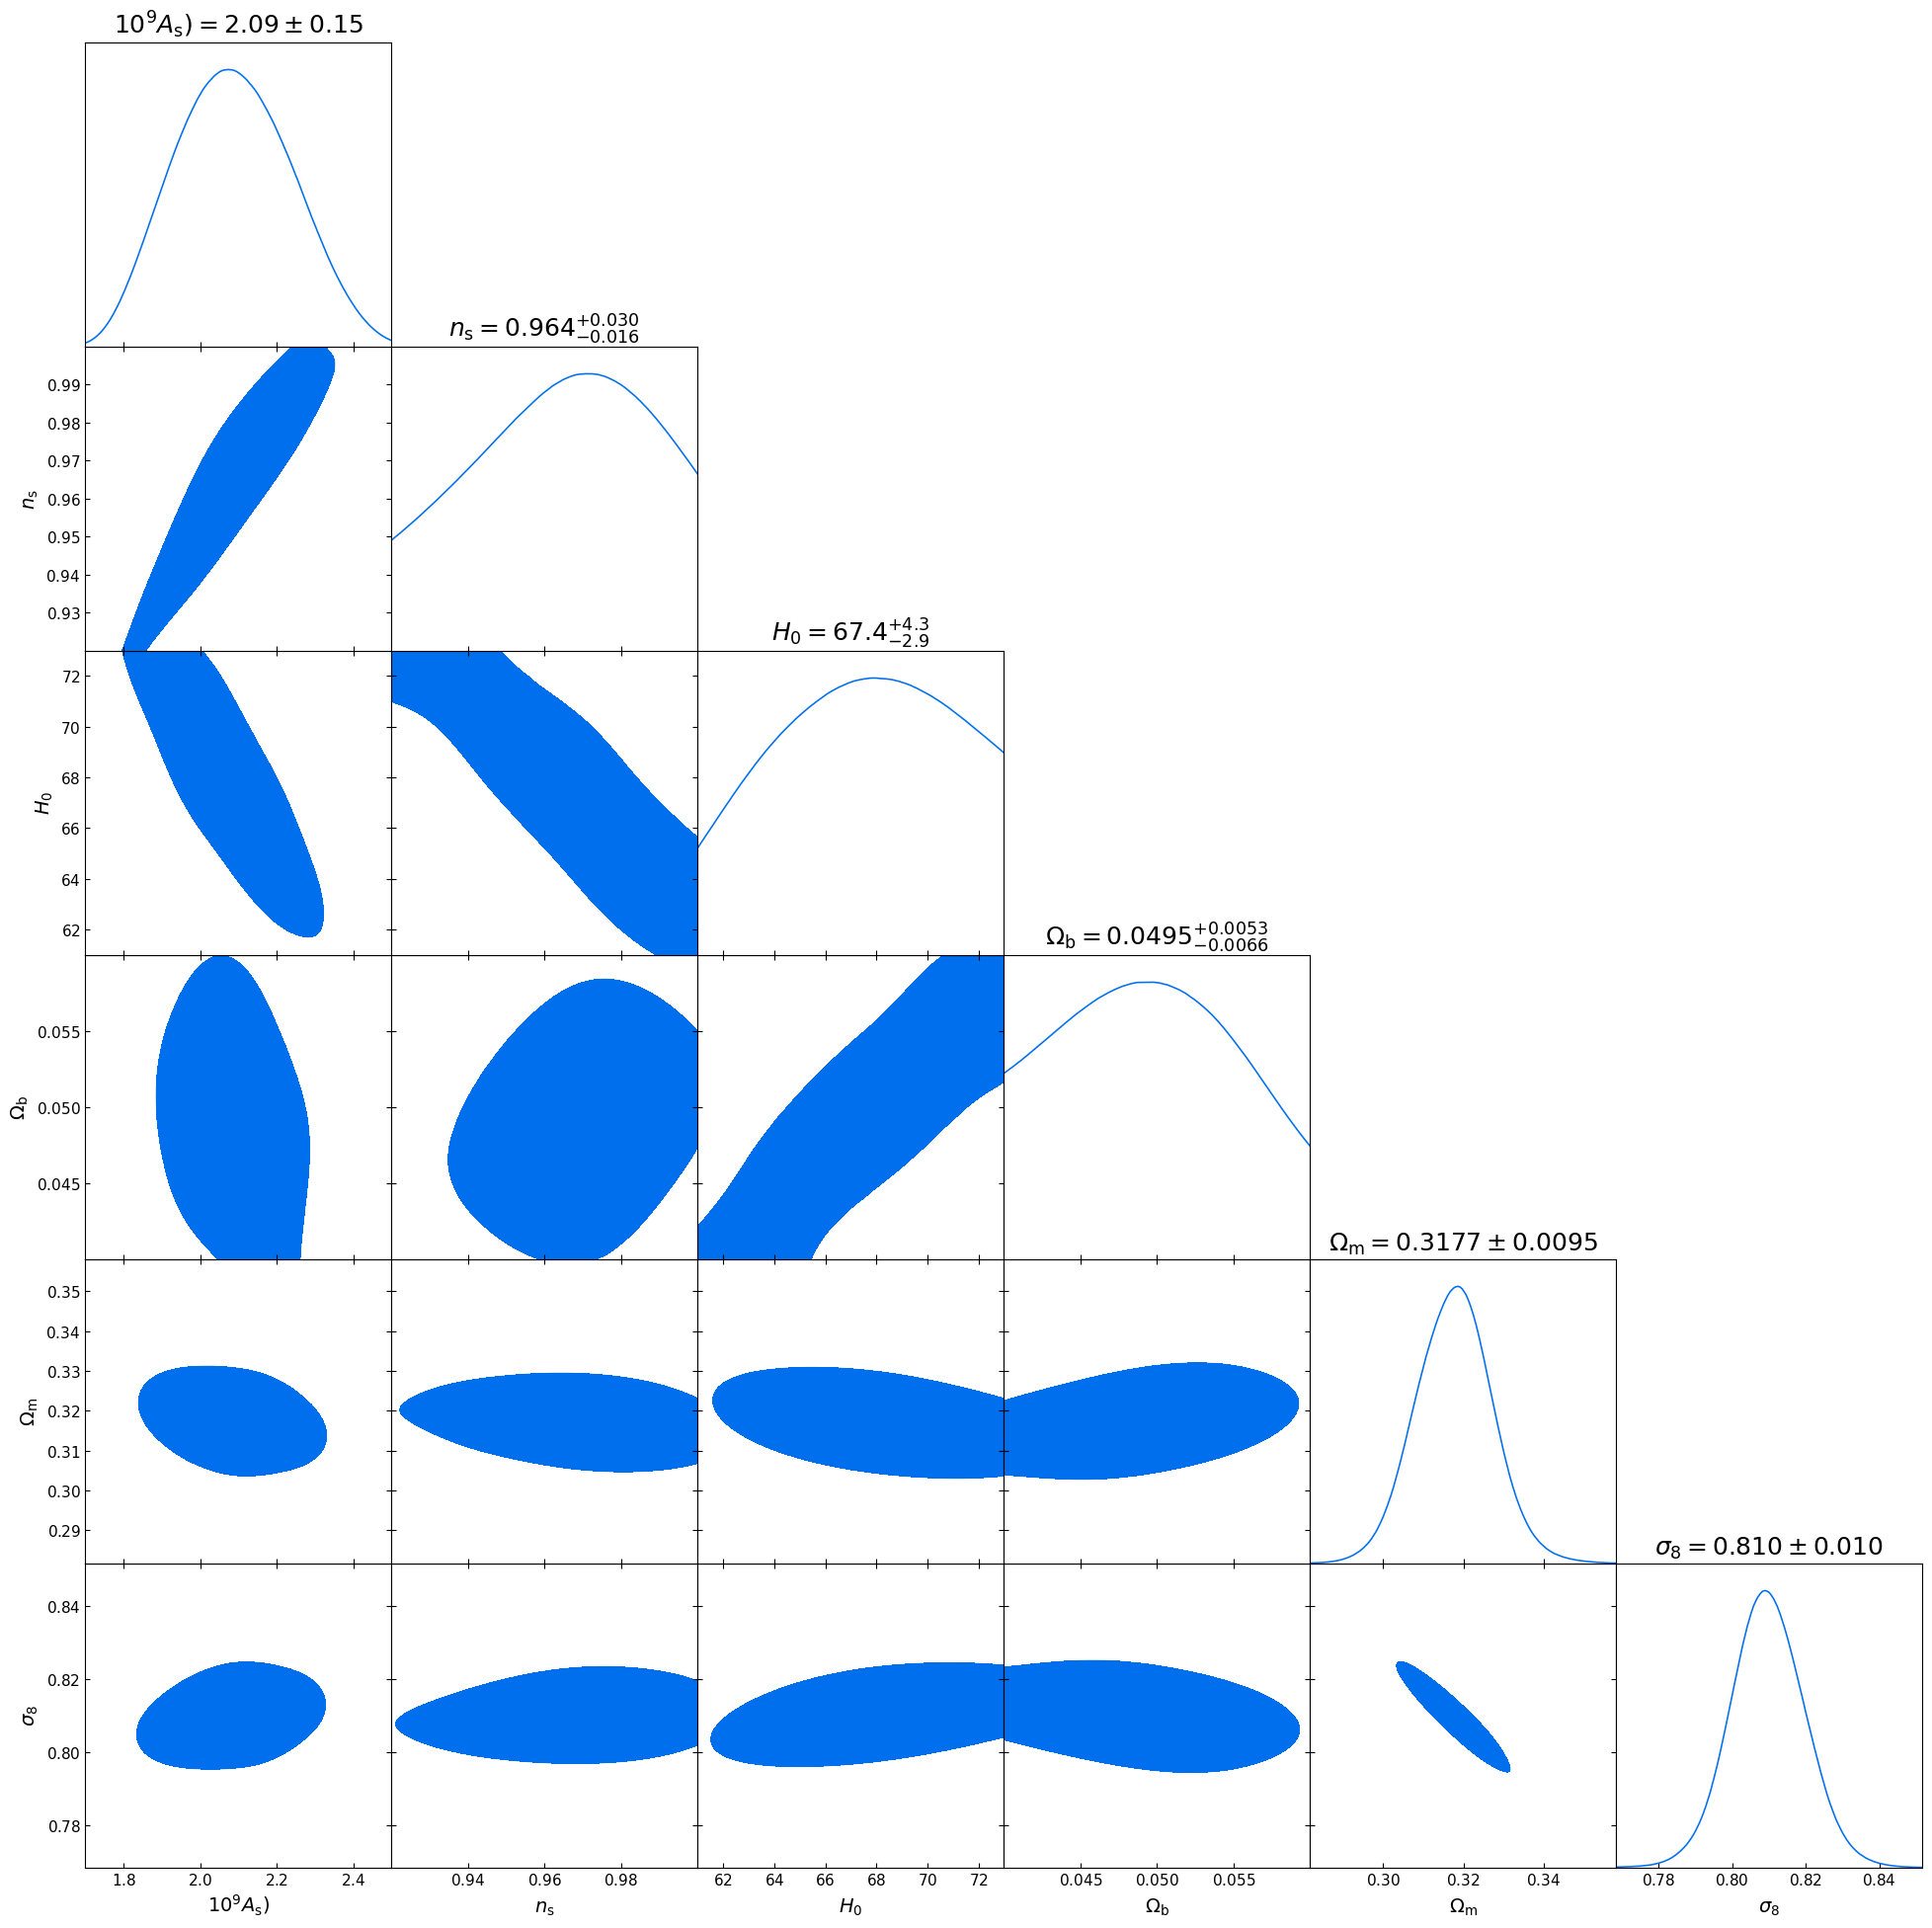

In [8]:
from getdist import plots
g = plots.get_subplot_plotter(subplot_size=4)
g.settings.title_limit = 1            
g.settings.title_limit_labels = True  
g.settings.title_limit_fontsize = 18
params = ['As_1e9','ns','H0','omegab','omegam','sigma8']
if choice==1:
    params = ['As_1e9','ns','H0','omegab','omegam','sigma8']

g.triangle_plot(samples, params=params, filled=True,
                marker_args={'ls':'--','lw':1.2,'color':'k','alpha':0.8})

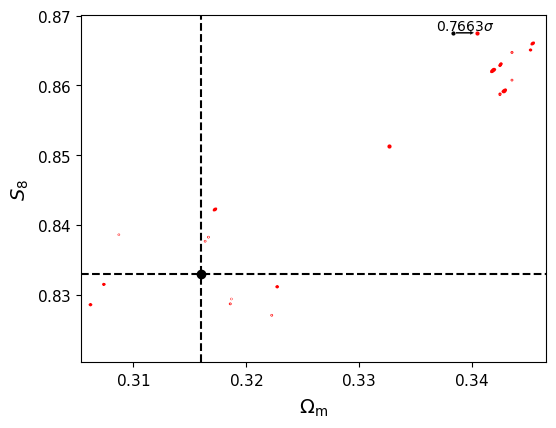

<Figure size 640x480 with 0 Axes>

In [28]:
def twocontours(samples:list, fiducials:dict={}, v1:str='omegam', v2:str='S8'):
    '''
    plot omegam-S8 omega-sigma8 countours with fiducial value and deviation\
        estimation if fiducials exist
        
    support maximum 3 samples to plot together
    '''
    #check if variable has fiducial value
    for v in [v1,v2]:
        if v not in fiducials:
            warnings.warn(f'no fiducial value for {v}')
            
    g = plots.get_single_plotter(width_inch=6)
    g.settings.tight_layout = False
    g.settings.legend_frac_subplot_margin = 0.05
    g.plot_2d(samples,
                param1 = v1,
                param2 = v2,
                filled=False,
                nx=1,
                legend_labels=['68%','68%','68%',],
                legend_ncol=3,
                colors=['r', 'g', 'b'],
                alphas=[1.0, 0.8, 0.6],
            )

    fig = plt.gcf()
    axes = fig.get_axes()
    ax = axes[0]
    ymin, ymax = ax.get_ylim()
    xmin, xmax = ax.get_xlim()
    
    #plot fiducial values
    fiducial1 = fiducials[v1]
    ax.axvline(x=fiducial1,linestyle='--',color='k')
    fiducial2 = fiducials[v2]
    ax.axhline(y=fiducial2,linestyle='--',color='k')
    ax.scatter(x=fiducial1,y=fiducial2,marker='o',color='k')
    
    mean_params = []
    for s, color in zip(samples, ['r','g','b']):
        mean_param1 = s.mean(v1)
        mean_param2 = s.mean(v2)
        ax.plot(mean_param1, mean_param2, marker='o', color=color, markersize=2, label=f'Center {color}')
        
        mean_params.append([mean_param1, mean_param2])

    mean_params = np.array(mean_params)

    #--------------calculate the chi2 and significance--------------------#
    chi2s = []
    for index,sample in enumerate(samples):
        cov_mat = sample.cov()
        i = sample.index[v1]
        j = sample.index[v2]
        cov = np.array([[cov_mat[i,i], cov_mat[i,j]],[cov_mat[i,j], cov_mat[j,j]]])

        chi2 = (np.array([fiducial1,fiducial2]) - mean_params[index])@sp.linalg.inv(cov)@(np.array([fiducial1,fiducial2]) - mean_params[index])
        chi2s.append(chi2)
        
        def nsigma2d(chi2):
            return np.sqrt(2)*sp.special.erfinv(1-np.exp(-1/2*chi2))

    #-----------plot and mark the significance----------------#
    from matplotlib.patches import FancyArrowPatch

    xratio = 0.8
    xs = [xmin + (xmax-xmin)*xratio for i in range(len(samples))]
    yratio = [0.95]
    ys = [ymin + (ymax-ymin)*yratio[i] for i in range(len(samples))]
    dx = (xmax-xmin)*0.05
    dy = 0


    colors = ['r','g','b']
    for i in range(len(samples)):
        ax.plot(xs[i], ys[i], marker='o', color='k', markersize=2)
        ax.plot(xs[i]+dx, ys[i], marker='o', color=colors[i], markersize=2)
        arrow = FancyArrowPatch(posA=(xs[i], ys[i]),
                                posB=(xs[i]+dx, ys[i]),
                                linewidth=0.1,
                                mutation_scale=5,
                                color='k')
        ax.add_patch(arrow)
        ax.text(xs[i]+dx/2, ys[i], rf'$ {nsigma2d(chi2s[i]):.4f}\sigma $', ha='center', va='bottom', fontsize=10)
    plt.show()
    plt.savefig(f'twocontour_{v1}_{v2}.png', dpi=400)
    return ax,fig


ax,fig = twocontours(samples=[samples], fiducials=fiducials, v1='omegam', v2='S8')

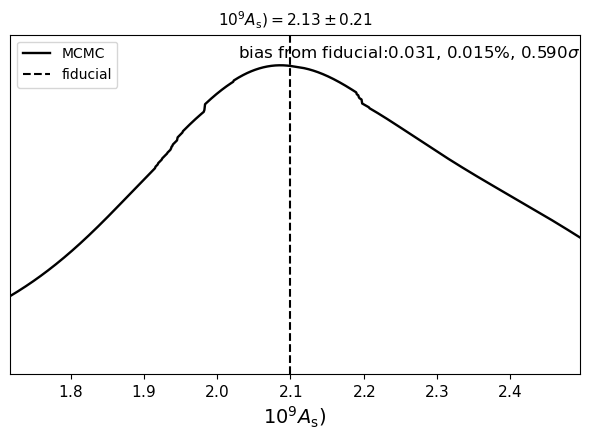

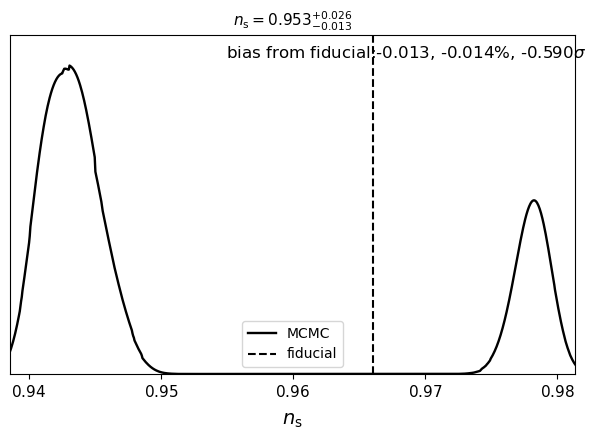

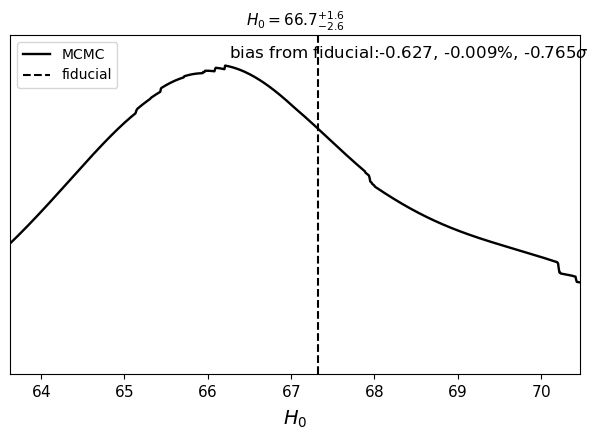

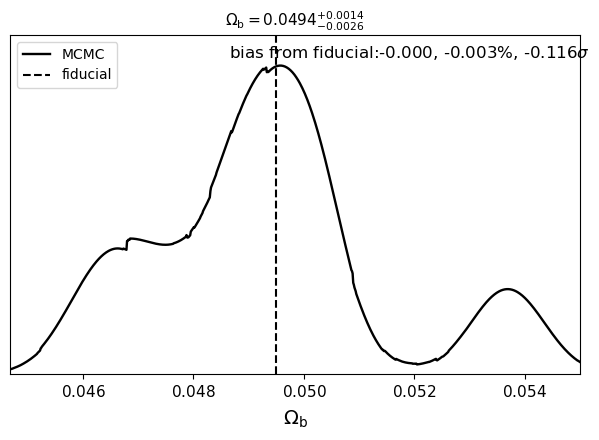

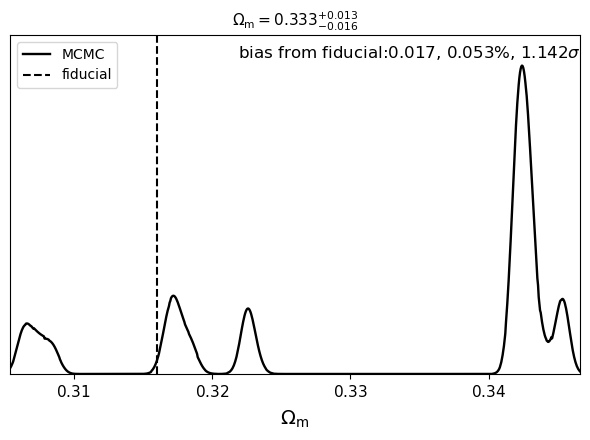

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


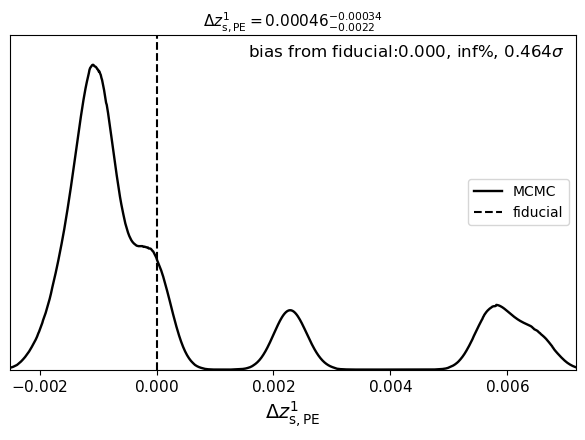

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


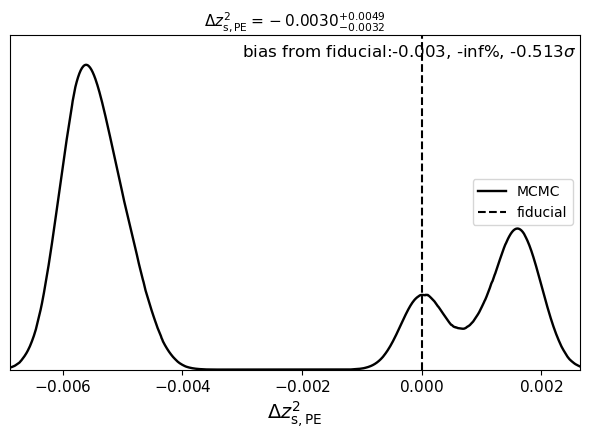

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


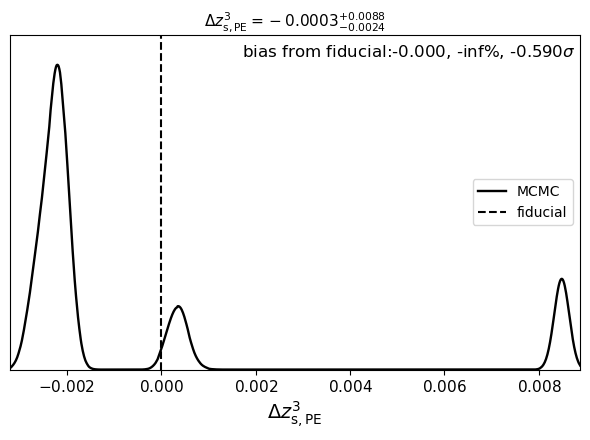

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


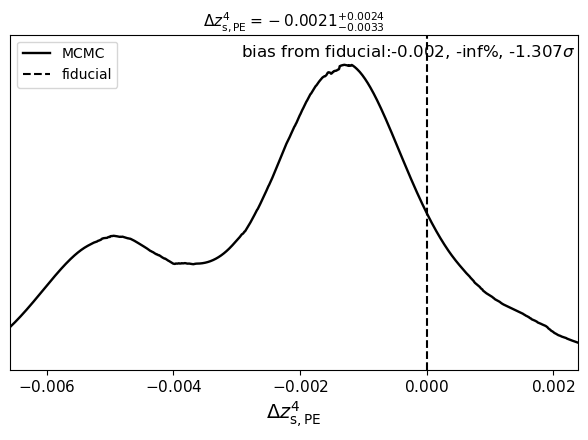

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


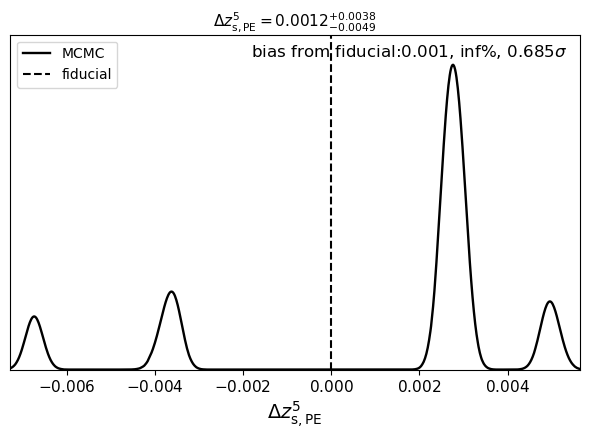

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


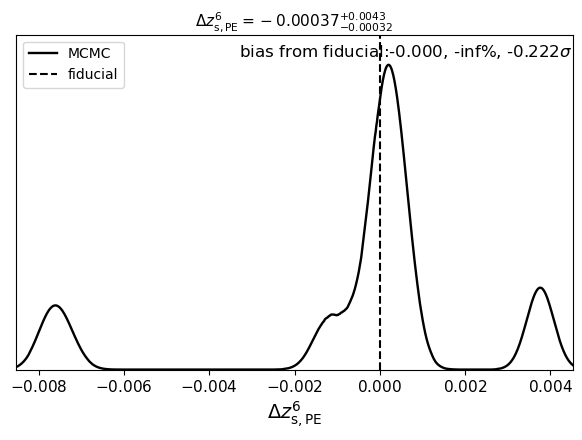

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


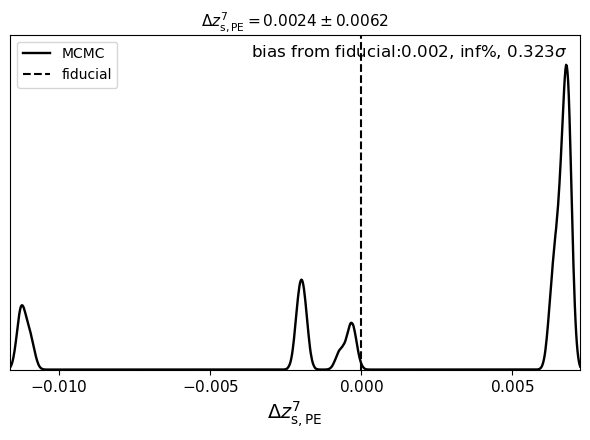

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


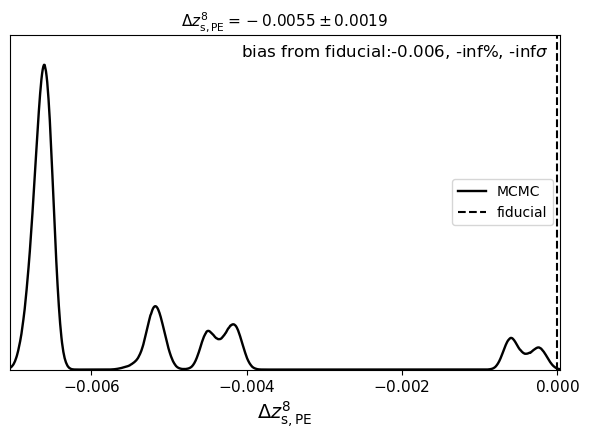

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


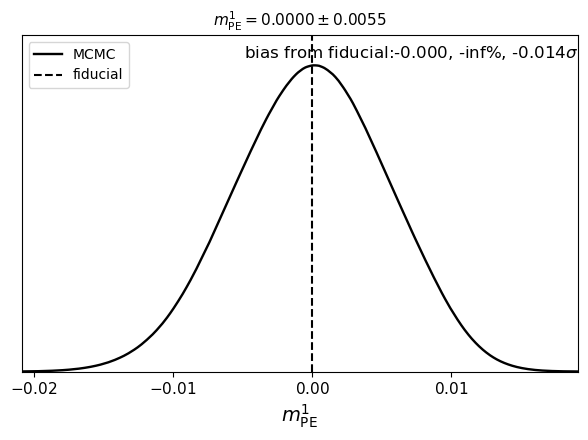

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


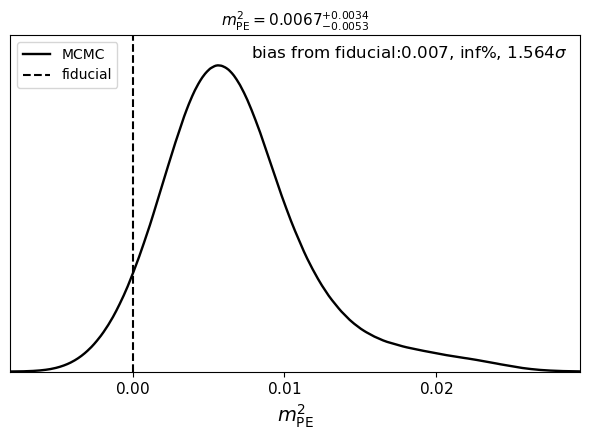

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


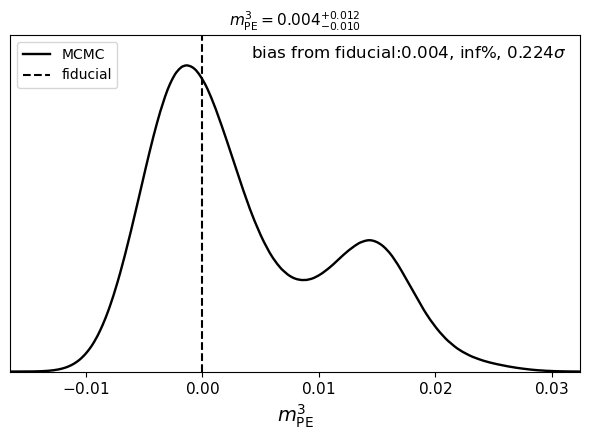

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


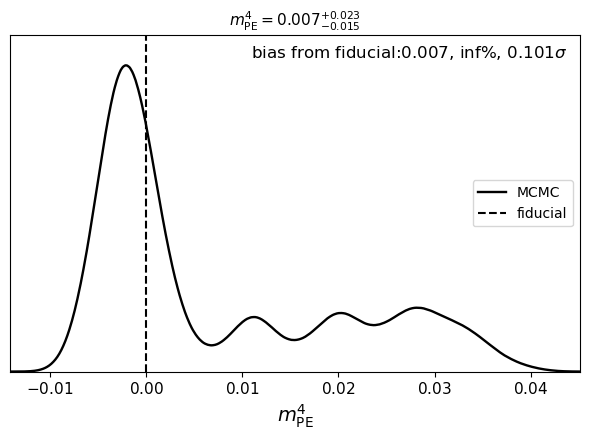

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


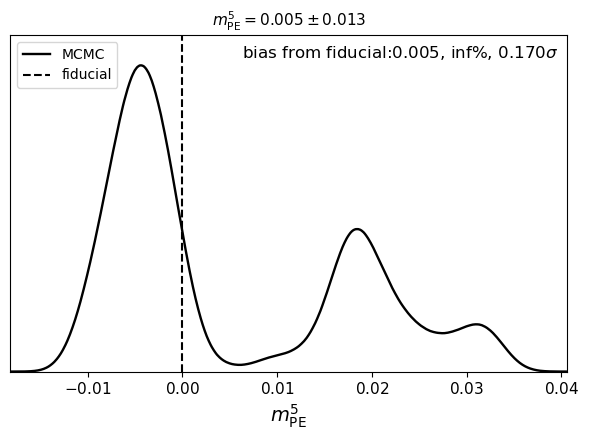

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


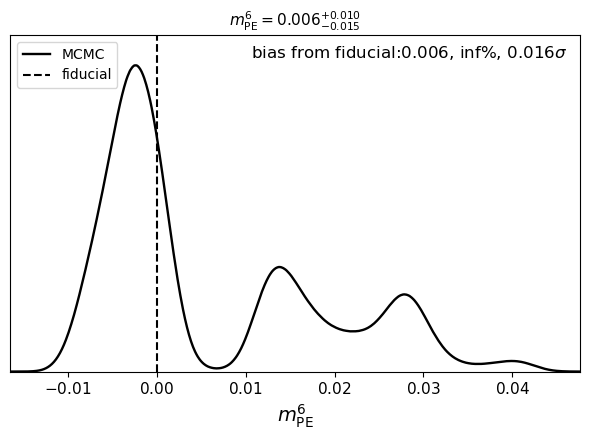

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


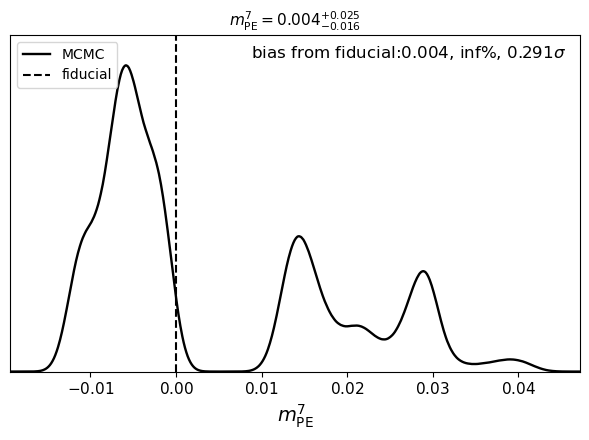

/home/junzhou/ipykernel_1553047/3712592595.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  bias_per = bias/fiducials[name]


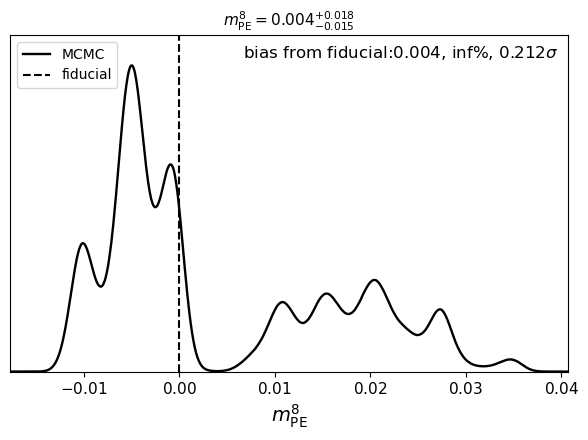

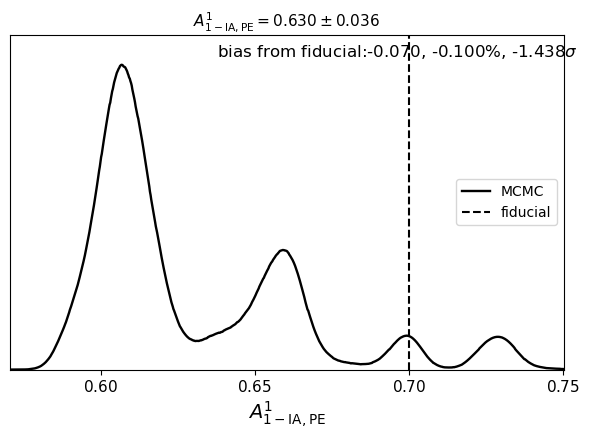

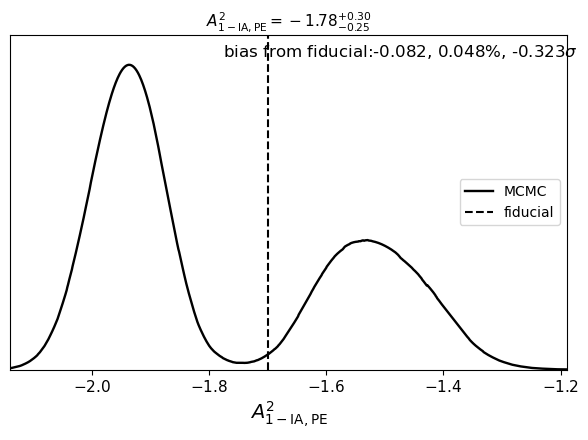

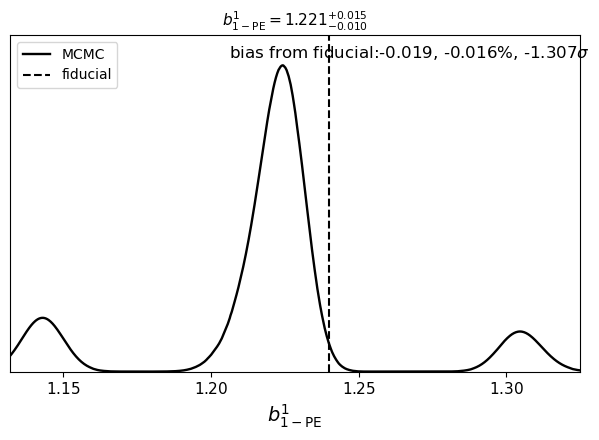

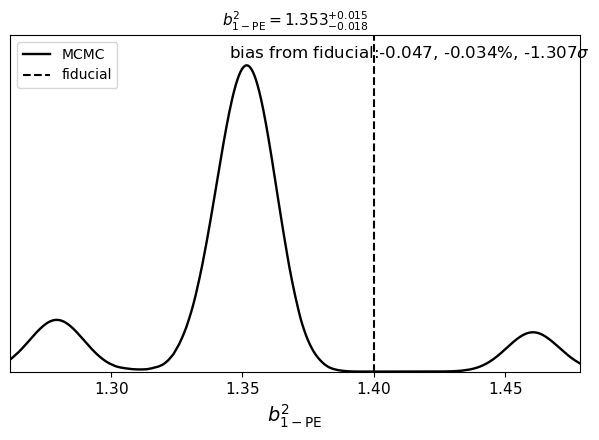

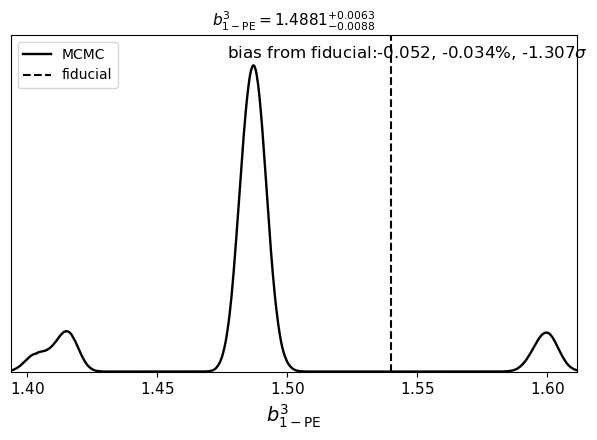

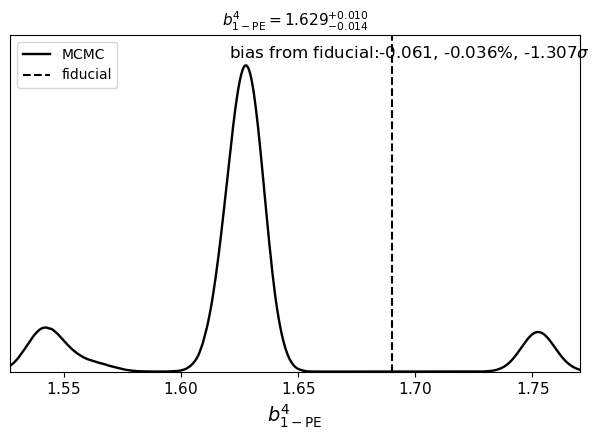

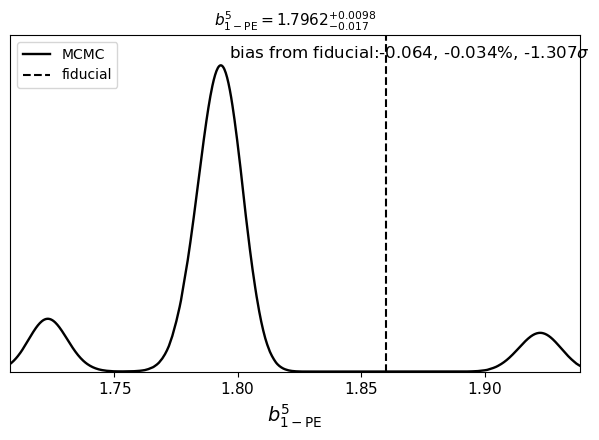

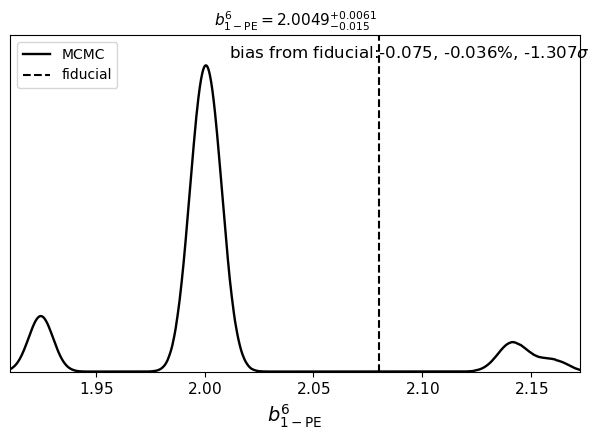

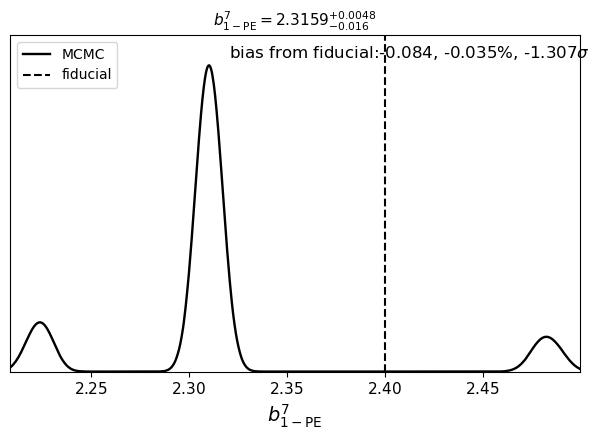

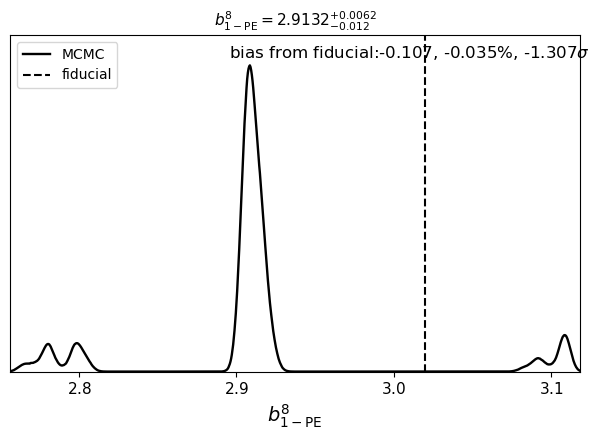

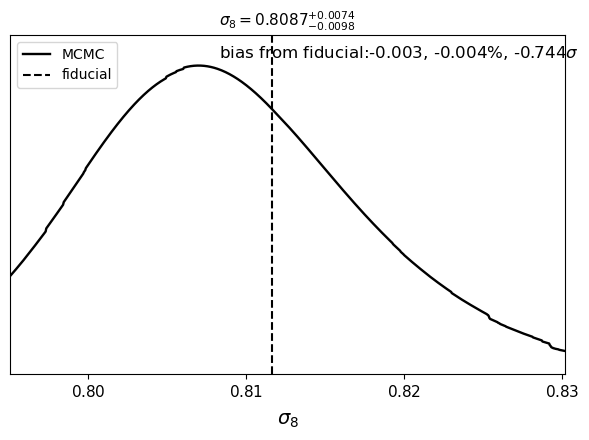

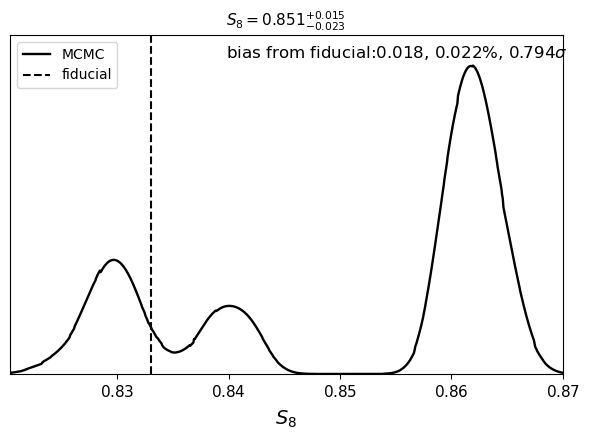

In [29]:
#g = plots.get_single_plotter(width_inch=6)
for p in samples.getParamNames().names:
    if p.name in fiducials:
        name = p.name
        mean = samples.mean(name)
        g = plots.get_single_plotter(width_inch=6)
        g.plot_1d(samples, name, title_limit=1)
        fig = plt.gcf()
        axes = fig.get_axes()
        ax = axes[0]
        ymin, ymax = ax.get_ylim()
        xmin, xmax = ax.get_xlim()
        
        ax.axvline(x = fiducials[name], ymin=0, ymax=1, linestyle='--', color='k')
        ax.legend(['MCMC', 'fiducial'])
        #----------------------------------
        x = getattr(samples.getParams(), name)
        w = samples.weights
        order = np.argsort(x)
        x_sorted = x[order]
        w_sorted = w[order]
        wcum = np.cumsum(w_sorted)
        wcum = wcum/wcum[-1]
        F = np.interp(fiducials[name], x_sorted, wcum, left=0.0, right=1.0)
        p_two = 2*min(F, 1-F)
        from scipy.stats import norm
        sigma_eq = norm.isf(p_two/2)
        #----------------------------------
        bias = mean - fiducials[name]
        bias_per = bias/fiducials[name]
        ax.text(xmin+(xmax-xmin)*0.7, ymin+(ymax-ymin)*0.92, rf'bias from fiducial:{bias:.3f}, {bias_per:.3f}%, {bias/np.abs(bias)*sigma_eq:.3f}$\sigma$', ha='center', va='bottom', fontsize=12)
        plt.show()
        